# MultiComponent Verification

This notebook creates the verification figure for the `MultiComponent` implementation. The scenario uses a two-mode switching-gain integrator with a known analytical reference. It isolates mode selection, state transfer, active-model delegation, and the `sync_events` log.

In [17]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "syssimx").exists() and (candidate / "thesis").exists():
            return candidate
    raise RuntimeError("Could not locate repository root")


REPO_ROOT = find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "thesis" / "notebooks"

for path in (REPO_ROOT, NOTEBOOK_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from plot_setup import FULL_WIDTH, set_professional_style
from syssimx.core.base import CoSimComponent
from syssimx.core.multi_comp import ModeKey, MultiComponent
from syssimx.core.port import PortSpec, PortType

set_professional_style(latex=True, fontsize=10)

<module 'matplotlib.pyplot' from 'c:\\Users\\flori\\anaconda3\\envs\\env-312\\Lib\\site-packages\\matplotlib\\pyplot.py'>

## Verification Model

The test model is intentionally minimal. Each internal model integrates the same scalar state with a different gain. The state format is identical in both modes, so `_adapt_state()` returns a copy of the same state dictionary.

In [18]:
class SwitchingGainComponent(CoSimComponent):
    """Scalar integrator with gain-dependent input dynamics."""

    def __init__(self, name: str, gain: float, x0: float = 0.0):
        super().__init__(name, label=name)
        self.gain = float(gain)
        self.x0 = float(x0)
        self.x = float(x0)
        self.step_log: list[tuple[float, float, float]] = []

        self.input_specs = {
            "u": PortSpec(name="u", type=PortType.REAL, direction="in"),
        }
        self.output_specs = {
            "x": PortSpec(name="x", type=PortType.REAL, direction="out"),
        }

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0
        self.step_log.clear()

    def _do_step_internal(self, t: float, dt: float) -> None:
        u = self.inputs["u"].get()
        self.x += self.gain * float(u) * dt
        self.step_log.append((t, dt, self.x))

    def _update_output_states(self, t: float | None = None, event_names: list[str] | None = None) -> None:
        self.outputs["x"].set(self.x, t=t)

    def get_state(self) -> dict[str, float]:
        return {"x": self.x}

    def set_state(self, state: dict[str, float], t: float) -> None:
        self.x = float(state["x"])
        self.t = t
        if "x" in self.outputs:
            self._update_output_states(t)


class SwitchingGainMultiComponent(MultiComponent):
    """Two-mode MultiComponent used only for thesis verification."""

    def __init__(self, name: str, k_a: float, k_b: float, initial_mode: ModeKey = "A"):
        self.k_a = float(k_a)
        self.k_b = float(k_b)
        super().__init__(name=name, initial_mode=initial_mode)
        self._register_models()
        self.active_comp = self.models[initial_mode]
        self._unify_ports()

    def _register_models(self) -> None:
        self.models = {
            "A": SwitchingGainComponent(f"{self.name}_A", gain=self.k_a),
            "B": SwitchingGainComponent(f"{self.name}_B", gain=self.k_b),
        }

    def _adapt_state(self, state: dict[str, float], target_mode: ModeKey) -> dict[str, float]:
        return {"x": float(state["x"])}

## Simulation Setup

The selector switches from mode A to mode B at `t_s = 0.5 s`. The analytical reference is piecewise linear.

In [19]:
k_a = 1.0
k_b = 2.0
u_const = 1.0
t_start = 0.0
t_switch = 0.5
t_end = 1.0
dt = 0.05


def analytical_x(t: np.ndarray | float) -> np.ndarray | float:
    t_arr = np.asarray(t)
    x = np.where(
        t_arr <= t_switch,
        k_a * u_const * t_arr,
        k_a * u_const * t_switch + k_b * u_const * (t_arr - t_switch),
    )
    if np.isscalar(t):
        return float(x)
    return x


multi = SwitchingGainMultiComponent("SwitchingGain", k_a=k_a, k_b=k_b, initial_mode="A")
multi.mode_selector = lambda t, state: "B" if t >= t_switch - 1e-12 else "A"
multi.initialize(t_start)

times = [multi.t]
x_num = [float(multi.outputs["x"].get())]
active_modes = [multi.active_mode]

n_steps = int(round((t_end - t_start) / dt))
for n in range(n_steps):
    t = t_start + n * dt
    multi.set_inputs({"u": u_const}, t=t)
    multi.do_step(t, dt)
    times.append(multi.t)
    x_num.append(float(multi.outputs["x"].get()))
    active_modes.append(multi.active_mode)

times = np.asarray(times)
x_num = np.asarray(x_num)
x_ref = analytical_x(times)
max_abs_error = float(np.max(np.abs(x_num - x_ref)))

sync_events = multi.sync_events
assert len(sync_events) == 1
assert sync_events[0]["from_mode"] == "A"
assert sync_events[0]["to_mode"] == "B"
assert np.isclose(sync_events[0]["time"], t_switch)
assert np.isclose(sync_events[0]["retrieved"]["x"], analytical_x(t_switch))
assert np.isclose(sync_events[0]["now"]["x"], analytical_x(t_switch))
assert max_abs_error < 1e-12

print(f"switch event: {sync_events[0]}")
print(f"mode A steps: {len(multi.models['A'].step_log)}")
print(f"mode B steps: {len(multi.models['B'].step_log)}")
print(f"max abs. error: {max_abs_error:.2e}")

switch event: {'time': 0.5, 'from_mode': 'A', 'to_mode': 'B', 'retrieved': {'x': 0.49999999999999994}, 'now': {'x': 0.49999999999999994}}
mode A steps: 10
mode B steps: 10
max abs. error: 3.33e-16


## Verification Figure

The upper panel compares the numerical trajectory with the analytical reference. The lower panel shows the active mode reconstructed from the accepted switch event.

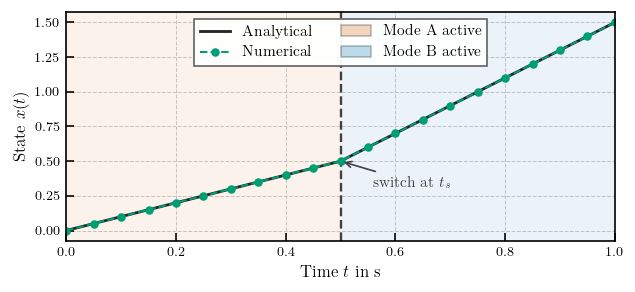

In [24]:
switch_time = sync_events[0]["time"]
t_dense = np.linspace(t_start, t_end, 400)

fig, ax = plt.subplots(
    1,
    1,
    figsize=(FULL_WIDTH, 0.42 * FULL_WIDTH),
)

mode_a_color = "#D55E00"
mode_b_color = "#0072B2"
num_color = "#009E73"
ref_color = "0.15"
switch_color = "0.25"

ax.axvspan(t_start, switch_time, color=mode_a_color, alpha=0.08, linewidth=0)
ax.axvspan(switch_time, t_end, color=mode_b_color, alpha=0.08, linewidth=0)
ax.axvline(switch_time, color=switch_color, linestyle="--", linewidth=1.4)

ax.grid(True)
ax.set_xlim(t_start, t_end)
ax.set_xlabel(r"Time $t$ in s")
ax.set_ylabel(r"State $x(t)$")

ax.plot(
    t_dense,
    analytical_x(t_dense),
    color=ref_color,
    linewidth=1.7,
)

ax.plot(
    times,
    x_num,
    color=num_color,
    linestyle="--",
    marker="o",
    linewidth=1.2,
)

ax.annotate(
    r"switch at $t_s$",
    xy=(switch_time, analytical_x(switch_time)),
    xytext=(switch_time + 0.06, analytical_x(switch_time) - 0.18),
    arrowprops=dict(arrowstyle="->", color=switch_color, lw=1),
    fontsize=9,
    color=switch_color,
)

handles = [
    Line2D([0], [0], color=ref_color, linewidth=1.7, label="Analytical"),
    Line2D([0], [0], color=num_color, linestyle="--", marker="o", linewidth=1.2, label="Numerical"),
    Patch(facecolor=mode_a_color, edgecolor="k", alpha=0.25, label="Mode A active"),
    Patch(facecolor=mode_b_color, edgecolor="k", alpha=0.25, label="Mode B active"),
]

ax.legend(handles=handles, ncol=2, loc="upper center")

out = REPO_ROOT / "thesis" / "figures" / "5_implementation" / "multi_component"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "multi_component_switching_verification.pdf")
plt.show()


## Verification Outcome

The assertions above check the accepted switch event, the transferred state, and the numerical agreement with the analytical reference. The figure is saved as `thesis/figures/5_implementation/multi_component/multi_component_switching_verification.pdf`.